=== DATASET OVERVIEW (FOR VIDEO) ===
Intents dataset shape: (1000, 3)

Intent class distribution:
 intent
accessory_search    114
price_query         107
payment             106
comparison          101
goodbye             100
greeting             99
recommendation       96
thanks               95
phone_search         94
availability         88
Name: count, dtype: int64

Sample rows:
                          text        intent                    response
507       Price of Galaxy S24   price_query   Response for price_query.
818  Is OnePlus 13 available?  availability  Response for availability.
452                 Thank you        thanks        Response for thanks.

Auxiliary datasets:
  Products: (930, 15), Accessories: (50, 8), Repairs: (30, 6), FAQ: (500, 3)

=== PREPROCESSING DEMO (FOR VIDEO) ===
BEFORE : Catch you later
AFTER  : catch later

=== ML MODEL (Random Forest) EVALUATION ===
Accuracy: 98.50%
                  precision    recall  f1-score   support

accessory_search    

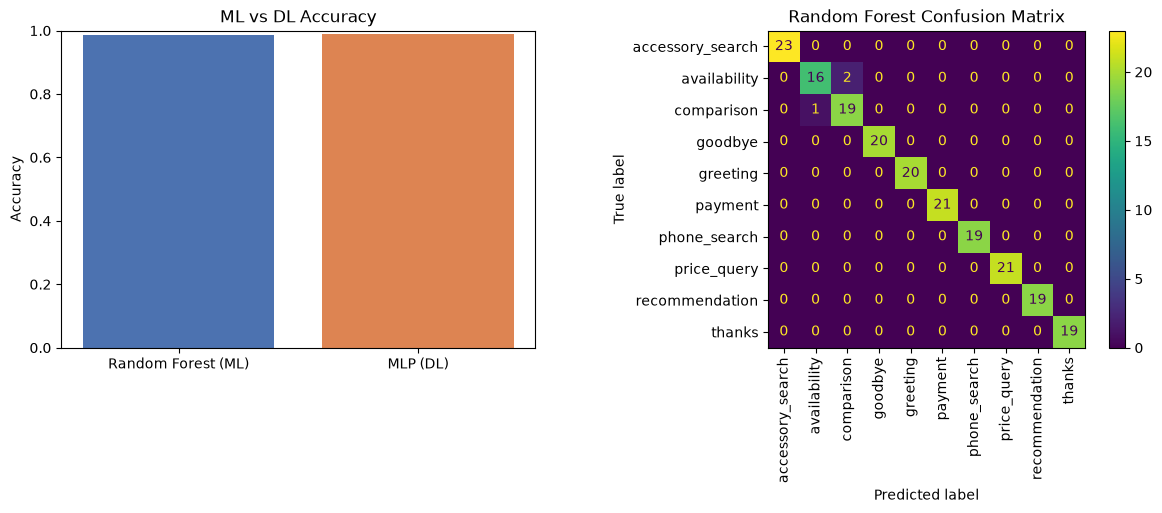

In [ ]:
"""
MOBIXA CHATBOT PIPELINE
========================
Stages (commit after each one — required for the progress video):
  1. Load & explore data          -> git commit "stage 1: dataset overview"
  2. Preprocessing                -> git commit "stage 2: text cleaning"
  3. Feature extraction (TF-IDF)  -> git commit "stage 3: feature extraction"
  4. ML model (Random Forest)     -> git commit "stage 4: ML model"
  5. DL model (MLP)               -> git commit "stage 5: DL model"
  6. Response lookup layer        -> git commit "stage 6: response generation"
  7. Save artifacts + live demo   -> git commit "stage 7: inference demo"
"""

import re
import difflib
import joblib
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

DATA_DIR = "../data"  # adjust to wherever your CSVs live


intents_df = pd.read_csv(f"{DATA_DIR}/mobixa_intents_1000.csv")
product_df = pd.read_csv(f"{DATA_DIR}/Product_Dataset.csv")
accessory_df = pd.read_csv(f"{DATA_DIR}/mobile_accessories_lkr-v2.csv")
repair_df = pd.read_csv(f"{DATA_DIR}/repair_services_lkr.csv")
faq_df = pd.read_csv(f"{DATA_DIR}/mobixa_faq_500.csv")

print("Intents dataset shape:", intents_df.shape)
print("\nIntent class distribution:\n", intents_df["intent"].value_counts())
print("\nSample rows:\n", intents_df.sample(3, random_state=1))
print("\nAuxiliary datasets:")
print(f"  Products: {product_df.shape}, Accessories: {accessory_df.shape}, "
      f"Repairs: {repair_df.shape}, FAQ: {faq_df.shape}")



nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


def clean_text(text):
    text = str(text).lower()
    tokens = re.findall(r"\b[a-z]+\b", text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)


intents_df["clean_text"] = intents_df["text"].apply(clean_text)

print("BEFORE :", intents_df["text"].iloc[0])
print("AFTER  :", intents_df["clean_text"].iloc[0])


tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(intents_df["clean_text"]).toarray()
y = intents_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


ml_model = RandomForestClassifier(n_estimators=100, random_state=42)
ml_model.fit(X_train, y_train)
y_pred_ml = ml_model.predict(X_test)
ml_accuracy = accuracy_score(y_test, y_pred_ml)

print("\n=== ML MODEL (Random Forest) EVALUATION ===")
print(f"Accuracy: {ml_accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred_ml))



dl_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
dl_model.fit(X_train, y_train)
y_pred_dl = dl_model.predict(X_test)
dl_accuracy = accuracy_score(y_test, y_pred_dl)

print("\n=== DL MODEL (Neural Network / MLP) EVALUATION ===")
print(f"Accuracy: {dl_accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred_dl))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["Random Forest (ML)", "MLP (DL)"], [ml_accuracy, dl_accuracy],
            color=["#4C72B0", "#DD8452"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("ML vs DL Accuracy")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ml, ax=axes[1], xticks_rotation=90)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
print("\nSaved comparison chart -> model_comparison.png")



STATIC_RESPONSES = {
    "greeting": "Hello! Welcome to Mobixa. How can I help you today?",
    "goodbye": "Thanks for visiting Mobixa. Have a great day!",
    "thanks": "You're welcome! Let us know if you need anything else.",
    "payment": "We accept cash, card, and online bank transfer.",
    "availability": "Could you tell me the product name so I can check stock for you?",
    "recommendation": "Sure — what's your budget and preferred brand?",
    "comparison": "Which two models would you like me to compare?",
}


def lookup_product(user_text):
    text_lower = user_text.lower()
    mask = product_df.apply(
        lambda r: r["Model Name"].lower() in text_lower
        or r["Company Name"].lower() in text_lower,
        axis=1,
    )
    matches = product_df[mask]
    if not matches.empty:
        row = matches.iloc[0]
        return (f"{row['Model Name']} ({row['Company Name']}) is priced at "
                f"{row['Price [LKR]']}. Stock: {row['Stock Status']}.")
    return "Could you tell me the exact phone model so I can check that for you?"


def lookup_accessory(user_text):
    text_lower = user_text.lower()
    mask = accessory_df.apply(
        lambda r: r["accessory_name"].lower() in text_lower
        or r["brand"].lower() in text_lower
        or r["category"].lower() in text_lower,
        axis=1,
    )
    matches = accessory_df[mask]
    if not matches.empty:
        row = matches.iloc[0]
        return (f"{row['accessory_name']} is priced at LKR {row['price_lkr']} "
                f"({row['stock']} in stock, {row['warranty']} warranty).")
    return "Which accessory are you looking for — charger, case, or something else?"


def lookup_faq(user_text, cutoff=0.5):
    """Fallback: fuzzy-match against the 500 FAQ questions."""
    questions = faq_df["question"].tolist()
    close = difflib.get_close_matches(user_text, questions, n=1, cutoff=cutoff)
    if close:
        return faq_df.loc[faq_df["question"] == close[0], "answer"].iloc[0]
    return None




def get_response(predicted_intent, user_text):
    if predicted_intent in ("price_query", "phone_search"):
        return lookup_product(user_text)
    if predicted_intent == "accessory_search":
        return lookup_accessory(user_text)
    if predicted_intent in STATIC_RESPONSES:
        return STATIC_RESPONSES[predicted_intent]

    faq_answer = lookup_faq(user_text)
    return faq_answer or "Sorry, could you rephrase that?"



joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(ml_model, "rf_model.joblib")
joblib.dump(dl_model, "mlp_model.joblib")
print("\nSaved: tfidf_vectorizer.joblib, rf_model.joblib, mlp_model.joblib")


def predict_response(user_text, model=ml_model):
    cleaned = clean_text(user_text)
    features = tfidf.transform([cleaned]).toarray()
    predicted_intent = model.predict(features)[0]
    reply = get_response(predicted_intent, user_text)
    return predicted_intent, reply


print("\n=== LIVE INFERENCE DEMO (FOR VIDEO) ===")
demo_queries = [
    "hi there",
    "how much is the iPhone 16 128GB",
    "do you have a Samsung fast charger",
    "thanks a lot",
    "is accidental damage covered in Kandy",
]
for q in demo_queries:
    intent, reply = predict_response(q)
    print(f"USER: {q}\n  -> intent: {intent}\n  -> reply : {reply}\n")


In [2]:
%pip install joblib matplotlib seaborn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-a


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install nltk pandas matplotlib joblib seaborn scikit-learn

  Using cached nltk-3.10.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached nltk-3.10.0-py3-none-any.whl (1.7 MB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl (280 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached click-8.4.2-py3-non


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
